## Assignment 1: RNN for Time Series Forecasting -

Task: You are provided with a hypothetical time series dataset (e.g., daily stock prices, sensor readings, or weather data). Design an experiment to evaluate the effectiveness of an RNN model (e.g., LSTM or GRU) for forecasting future values in this series. Your design should include:

In [1]:
# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

### Data Generation (Replace with your actual dataset loading and initial exploration)

For demonstration purposes, we'll generate a synthetic time series. In your actual assignment, you will load and explore your given dataset.

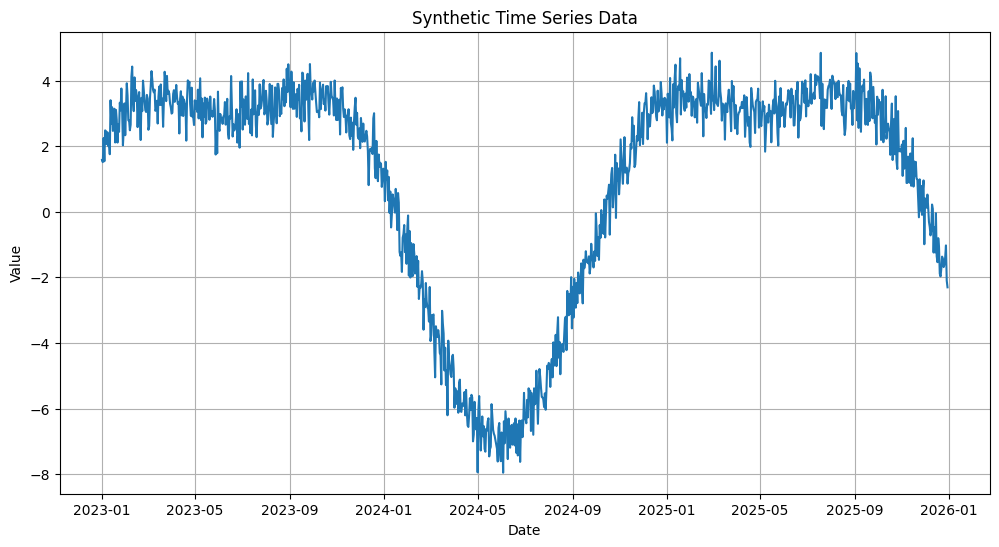

In [2]:
# Generate synthetic time series data
def generate_time_series(num_points):
    time = np.linspace(0, 100, num_points)
    data = 5 * np.sin(time / 10) + 2 * np.cos(time / 5) + np.random.normal(0, 0.5, num_points)
    return pd.Series(data, index=pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_points, freq='D')))

num_points = 365 * 3 # 3 years of daily data
time_series = generate_time_series(num_points)

plt.figure(figsize=(12, 6))
plt.plot(time_series)
plt.title('Synthetic Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

### Data Preprocessing

This involves scaling the data and creating sequences (windows) for the RNN model. You'll need to define `look_back` (number of previous time steps to consider) and `forecast_horizon` (number of future steps to predict).

In [3]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(time_series.values.reshape(-1, 1))


In [4]:

# Define look-back window and forecast horizon
look_back = 30 # Number of previous time steps to use as input
forecast_horizon = 1 # Number of future time steps to predict


In [5]:

# Function to create dataset with look-back windows
def create_dataset(data, look_back=1, forecast_horizon=1):
    X, Y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        X.append(data[i:(i + look_back), 0])
        Y.append(data[i + look_back : i + look_back + forecast_horizon, 0])
    return np.array(X), np.array(Y)


In [6]:

X, y = create_dataset(scaled_data, look_back, forecast_horizon)

# Reshape input to be [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (targets): {y.shape}")


Shape of X (features): (1065, 30, 1)
Shape of y (targets): (1065, 1)


In [7]:

# Split data into training and testing sets
# Use a time-based split for time series data
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size,:], X[train_size:len(X),:]
y_train, y_test = y[0:train_size,:], y[train_size:len(y),:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (852, 30, 1), y_train shape: (852, 1)
X_test shape: (213, 30, 1), y_test shape: (213, 1)


### Model Configuration (Example LSTM Model)

This is a basic LSTM model. You should experiment with different architectures, layers, and hyperparameters.

In [8]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(look_back, 1)))
model.add(Dense(forecast_horizon))
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

### Training and Evaluation Strategy

Train the model and then evaluate its performance on the test set. Remember to inverse transform the predictions to get actual values.

In [9]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=2, validation_split=0.2)


Epoch 1/50
22/22 - 2s - 111ms/step - loss: 0.2013 - val_loss: 0.0067
Epoch 2/50
22/22 - 0s - 16ms/step - loss: 0.0127 - val_loss: 0.0021
Epoch 3/50
22/22 - 0s - 16ms/step - loss: 0.0044 - val_loss: 0.0020
Epoch 4/50
22/22 - 0s - 17ms/step - loss: 0.0033 - val_loss: 0.0018
Epoch 5/50
22/22 - 0s - 16ms/step - loss: 0.0028 - val_loss: 0.0019
Epoch 6/50
22/22 - 0s - 16ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 7/50
22/22 - 0s - 16ms/step - loss: 0.0026 - val_loss: 0.0017
Epoch 8/50
22/22 - 0s - 18ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 9/50
22/22 - 0s - 18ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 10/50
22/22 - 0s - 18ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 11/50
22/22 - 0s - 20ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 12/50
22/22 - 0s - 18ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 13/50
22/22 - 0s - 17ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 14/50
22/22 - 0s - 17ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 15/50
22/22 - 0s - 18ms/step - loss:

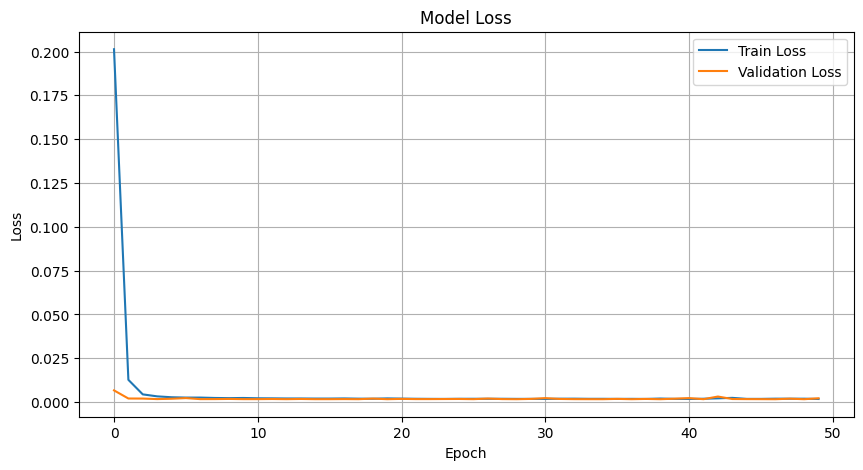

In [10]:

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [11]:

# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [12]:

# Inverse transform predictions and actual values
y_train_pred_inv = scaler.inverse_transform(y_train_pred)
y_train_inv = scaler.inverse_transform(y_train)
y_test_pred_inv = scaler.inverse_transform(y_test_pred)
y_test_inv = scaler.inverse_transform(y_test)


Train RMSE: 0.593, MAE: 0.479
Test RMSE: 0.605, MAE: 0.498


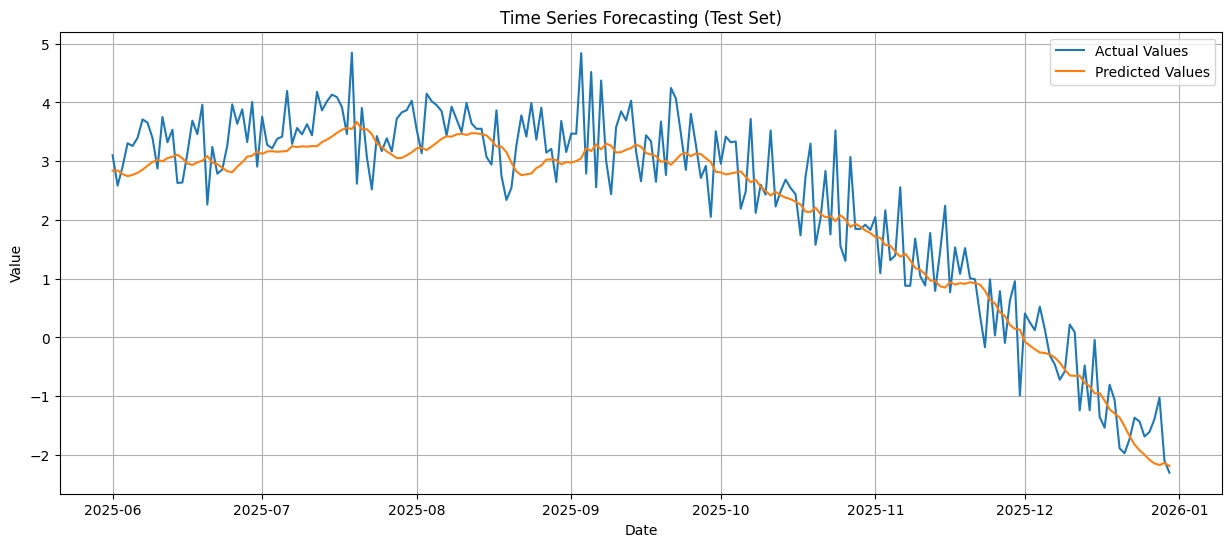

In [13]:

# Calculate evaluation metrics
rmse_train = np.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
mae_train = mean_absolute_error(y_train_inv, y_train_pred_inv)

rmse_test = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
mae_test = mean_absolute_error(y_test_inv, y_test_pred_inv)

print(f'Train RMSE: {rmse_train:.3f}, MAE: {mae_train:.3f}')
print(f'Test RMSE: {rmse_test:.3f}, MAE: {mae_test:.3f}')

# Plot actual vs. predicted (for a segment of the test data)
plt.figure(figsize=(15, 6))
plt.plot(time_series.index[-len(y_test_inv):], y_test_inv, label='Actual Values')
plt.plot(time_series.index[-len(y_test_pred_inv):], y_test_pred_inv, label='Predicted Values')
plt.title('Time Series Forecasting (Test Set)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Error Analysis Considerations

After running this starter code, critically analyze the results. If the model performance is not satisfactory, consider the following points for your error analysis as outlined in Assignment 2:

*   **Hypothesis 1: Insufficient Feature Engineering/Preprocessing.**
    *   **Test:** Experiment with different `look_back` windows, feature scaling methods (e.g., standard scaler), or adding external features if available (e.g., day of week, holidays, trends).
*   **Hypothesis 2: Model Complexity Mismatch.**
    *   **Test:** Try increasing or decreasing the number of LSTM units, adding more LSTM layers, or exploring other RNN types like GRU. Also, check for overfitting/underfitting by monitoring train vs. validation loss.
*   **Hypothesis 3: Suboptimal Hyperparameters.**
    *   **Test:** Experiment with different learning rates for the optimizer, batch sizes, and a larger number of epochs. Consider using techniques like early stopping.
*   **Hypothesis 4: Data Quality Issues.**
    *   **Test:** Re-examine the raw data for anomalies, missing values, or significant outliers that were not properly handled during initial preprocessing.

#Assignment 2

Build LSTM model for Patient Monitoring: Analyzing real-time, time-series data like heart rate, ECG, and blood pressure to predict critical events.dataset provided patient_monitoring.csv

In [14]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/patient_monitoring (1).csv')

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(data.head())

# Display information about the dataset
print("\nDataset Information:")
data.info()

First 5 rows of the dataset:
   Unnamed: 0  heart_rate  sys_bp  dia_bp     ecg  event
0           0       101.0   124.0    79.0 -0.9539      1
1           1       100.0   123.0    80.0 -0.4302      0
2           2       102.0   120.0    78.0 -0.2068      0
3           3       104.0   118.0    79.0  0.9438      0
4           4       100.0   122.0    76.0  0.2783      0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   heart_rate  1000 non-null   float64
 2   sys_bp      1000 non-null   float64
 3   dia_bp      1000 non-null   float64
 4   ecg         1000 non-null   float64
 5   event       1000 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 47.0 KB


In [15]:
from sklearn.preprocessing import MinMaxScaler

# Drop the 'Unnamed: 0' column if it exists and is an index
data = data.drop(columns=['Unnamed: 0'], errors='ignore')

# Separate features and target
# Features: heart_rate, sys_bp, dia_bp, ecg
# Target: event
features = data[['heart_rate', 'sys_bp', 'dia_bp', 'ecg']]
target = data['event']

# Scale the features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler.fit_transform(features)

print("Shape of scaled features:", scaled_features.shape)
print("Shape of target:", target.shape)
print("First 5 rows of scaled features:\n", scaled_features[:5])
print("First 5 values of target:\n", target.head())

Shape of scaled features: (1000, 4)
Shape of target: (1000,)
First 5 rows of scaled features:
 [[0.55172414 0.60606061 0.375      0.16551098]
 [0.51724138 0.57575758 0.4375     0.33520187]
 [0.5862069  0.48484848 0.3125     0.40758862]
 [0.65517241 0.42424242 0.375      0.78040957]
 [0.51724138 0.54545455 0.1875     0.56477221]]
First 5 values of target:
 0    1
1    0
2    0
3    0
4    0
Name: event, dtype: int64


In [16]:
import numpy as np

look_back_patient = 30 # Example: look at the last 30 time steps of data

# Prepare X (features) and y (target) for the LSTM
X_patient, y_patient = [], []

for i in range(len(scaled_features) - look_back_patient):
    X_patient.append(scaled_features[i:(i + look_back_patient), :])
    y_patient.append(target[i + look_back_patient])

# Convert lists to numpy arrays
X_patient = np.array(X_patient)
y_patient = np.array(y_patient)

print(f"Shape of X_patient (sequences of features): {X_patient.shape}")
print(f"Shape of y_patient (corresponding events): {y_patient.shape}")

Shape of X_patient (sequences of features): (970, 30, 4)
Shape of y_patient (corresponding events): (970,)


In [17]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (time-based split)
train_size_patient = int(len(X_patient) * 0.8)

X_train_patient, X_test_patient = X_patient[0:train_size_patient,:], X_patient[train_size_patient:len(X_patient),:]
y_train_patient, y_test_patient = y_patient[0:train_size_patient], y_patient[train_size_patient:len(y_patient)]

print(f"X_train_patient shape: {X_train_patient.shape}, y_train_patient shape: {y_train_patient.shape}")
print(f"X_test_patient shape: {X_test_patient.shape}, y_test_patient shape: {y_test_patient.shape}")

X_train_patient shape: (776, 30, 4), y_train_patient shape: (776,)
X_test_patient shape: (194, 30, 4), y_test_patient shape: (194,)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define the number of features (heart_rate, sys_bp, dia_bp, ecg)
n_features = scaled_features.shape[1]

# Build the LSTM model for classification
model_patient = Sequential()
model_patient.add(LSTM(units=50, activation='relu', input_shape=(look_back_patient, n_features)))
model_patient.add(Dense(units=1, activation='sigmoid')) # Output layer for binary classification

# Compile the model
model_patient.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model_patient.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
from imblearn.over_sampling import RandomOverSampler

# Reshape X_train_patient for RandomOverSampler (2D input)
X_train_patient_2d = X_train_patient.reshape(X_train_patient.shape[0], -1)

# Apply RandomOverSampler to the training data
ros = RandomOverSampler(random_state=42)
X_train_resampled_2d, y_train_resampled = ros.fit_resample(X_train_patient_2d, y_train_patient)

# Reshape X_train_resampled_2d back to 3D for LSTM
X_train_resampled = X_train_resampled_2d.reshape(X_train_resampled_2d.shape[0], look_back_patient, n_features)

print("Original training shapes:", X_train_patient.shape, y_train_patient.shape)
print("Resampled training shapes:", X_train_resampled.shape, y_train_resampled.shape)

# Re-initialize and train the model with resampled data
# We'll re-create the model to ensure a fresh start, as it might have learned bad weights
model_patient_resampled = Sequential()
model_patient_resampled.add(LSTM(units=50, activation='relu', input_shape=(look_back_patient, n_features)))
model_patient_resampled.add(Dense(units=1, activation='sigmoid'))

model_patient_resampled.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining model with resampled data...")
history_patient_resampled = model_patient_resampled.fit(
    X_train_resampled, y_train_resampled,
    epochs=50, batch_size=32, verbose=2,
    validation_split=0.2 # Use validation split on resampled data
)

Original training shapes: (776, 30, 4) (776,)
Resampled training shapes: (1490, 30, 4) (1490,)

Training model with resampled data...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
38/38 - 4s - 118ms/step - accuracy: 0.6250 - loss: 0.6654 - val_accuracy: 0.0000e+00 - val_loss: 0.8933
Epoch 2/50
38/38 - 1s - 15ms/step - accuracy: 0.6250 - loss: 0.5567 - val_accuracy: 0.0000e+00 - val_loss: 0.7574
Epoch 3/50
38/38 - 1s - 15ms/step - accuracy: 0.7240 - loss: 0.4252 - val_accuracy: 0.7114 - val_loss: 0.6932
Epoch 4/50
38/38 - 1s - 15ms/step - accuracy: 0.7743 - loss: 0.4264 - val_accuracy: 0.7315 - val_loss: 0.6894
Epoch 5/50
38/38 - 1s - 16ms/step - accuracy: 0.7743 - loss: 0.4105 - val_accuracy: 0.9497 - val_loss: 0.5774
Epoch 6/50
38/38 - 1s - 15ms/step - accuracy: 0.7961 - loss: 0.3975 - val_accuracy: 0.9631 - val_loss: 0.5191
Epoch 7/50
38/38 - 1s - 17ms/step - accuracy: 0.8045 - loss: 0.3888 - val_accuracy: 0.9094 - val_loss: 0.5870
Epoch 8/50
38/38 - 1s - 16ms/step - accuracy: 0.8163 - loss: 0.3623 - val_accuracy: 0.9631 - val_loss: 0.4873
Epoch 9/50
38/38 - 1s - 16ms/step - accuracy: 0.8138 - loss: 0.3604 - val_accuracy: 0.9430 - val_loss: 0.5280
E

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set using the resampled model
y_pred_proba_resampled = model_patient_resampled.predict(X_test_patient)

# Define a prediction threshold (start with 0.5, or adjust as needed)
prediction_threshold_resampled = 0.1 # Lowering the threshold to capture more positive predictions

# Convert probabilities to binary predictions
y_pred_resampled = (y_pred_proba_resampled > prediction_threshold_resampled).astype(int)

# Evaluate the model trained with resampled data
accuracy_resampled = accuracy_score(y_test_patient, y_pred_resampled)
precision_resampled = precision_score(y_test_patient, y_pred_resampled)
recall_resampled = recall_score(y_test_patient, y_pred_resampled)
f1_resampled = f1_score(y_test_patient, y_pred_resampled)
conf_matrix_resampled = confusion_matrix(y_test_patient, y_pred_resampled)

print(f"Prediction Threshold (Resampled Model): {prediction_threshold_resampled}")
print(f"Test Accuracy (Resampled Model): {accuracy_resampled:.4f}")
print(f"Test Precision (Resampled Model): {precision_resampled:.4f}")
print(f"Test Recall (Resampled Model): {recall_resampled:.4f}")
print(f"Test F1-Score (Resampled Model): {f1_resampled:.4f}")
print("\nConfusion Matrix (Resampled Model):")
print(conf_matrix_resampled)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Prediction Threshold (Resampled Model): 0.1
Test Accuracy (Resampled Model): 0.7629
Test Precision (Resampled Model): 0.0222
Test Recall (Resampled Model): 0.3333
Test F1-Score (Resampled Model): 0.0417

Confusion Matrix (Resampled Model):
[[147  44]
 [  2   1]]


In [29]:
from scipy.stats import skew, kurtosis

def create_engineered_dataset(data, look_back_patient, n_features):
    X_engineered, y_engineered = [], []

    for i in range(len(data) - look_back_patient):
        # Extract the current window of features
        window = data[i:(i + look_back_patient), :]

        # --- Feature Engineering within the window ---
        features_in_window = []
        for j in range(n_features):
            series = window[:, j] # Get the j-th feature series in the window

            # Basic statistics
            features_in_window.append(np.mean(series))
            features_in_window.append(np.std(series))
            features_in_window.append(np.min(series))
            features_in_window.append(np.max(series))
            features_in_window.append(np.median(series))
            features_in_window.append(skew(series))
            features_in_window.append(kurtosis(series))

            # Rate of change (simple difference between start and end of window)
            features_in_window.append(series[-1] - series[0])

            # Add the raw current value as well
            features_in_window.append(series[-1])

        X_engineered.append(features_in_window)
        y_engineered.append(target[i + look_back_patient])

    return np.array(X_engineered), np.array(y_engineered)

# Assuming 'scaled_features' and 'target' are already defined and 'n_features' is 4
# n_features was defined earlier as scaled_features.shape[1]

print(f"Original scaled_features shape: {scaled_features.shape}")

X_patient_engineered, y_patient_engineered = create_engineered_dataset(scaled_features, look_back_patient, n_features)

print(f"Shape of X_patient_engineered: {X_patient_engineered.shape}")
print(f"Shape of y_patient_engineered: {y_patient_engineered.shape}")

# Now split the engineered data into train and test sets
# Use a time-based split for time series data
train_size_engineered = int(len(X_patient_engineered) * 0.8)

X_train_patient_engineered, X_test_patient_engineered = X_patient_engineered[0:train_size_engineered,:], X_patient_engineered[train_size_engineered:len(X_patient_engineered),:]
y_train_patient_engineered, y_test_patient_engineered = y_patient_engineered[0:train_size_engineered], y_patient_engineered[train_size_engineered:len(y_patient_engineered)]

# Reshape X for LSTM [samples, time steps, features]. Here, 'time steps' will be 1 as we are passing aggregated features for each window.
# The 'features' dimension will be the number of engineered features per original feature, multiplied by the number of original features.
num_engineered_features_per_original = 9 # mean, std, min, max, median, skew, kurtosis, rate_of_change, current_value
num_total_engineered_features = n_features * num_engineered_features_per_original

X_train_patient_engineered = X_train_patient_engineered.reshape(X_train_patient_engineered.shape[0], 1, num_total_engineered_features)
X_test_patient_engineered = X_test_patient_engineered.reshape(X_test_patient_engineered.shape[0], 1, num_total_engineered_features)

print(f"X_train_patient_engineered shape: {X_train_patient_engineered.shape}, y_train_patient_engineered shape: {y_train_patient_engineered.shape}")
print(f"X_test_patient_engineered shape: {X_test_patient_engineered.shape}, y_test_patient_engineered shape: {y_test_patient_engineered.shape}")

# Re-initialize and train a new model with engineered features
model_patient_engineered = Sequential()
model_patient_engineered.add(LSTM(units=50, activation='relu', input_shape=(1, num_total_engineered_features)))
model_patient_engineered.add(Dense(units=1, activation='sigmoid'))

model_patient_engineered.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining model with engineered features...")
# Apply class weights again, as the dataset is still imbalanced
class_weights_engineered = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_patient_engineered),
    y=y_train_patient_engineered
)
class_weights_engineered_dict = dict(enumerate(class_weights_engineered))

history_patient_engineered = model_patient_engineered.fit(
    X_train_patient_engineered, y_train_patient_engineered,
    epochs=50, batch_size=32, verbose=2,
    validation_split=0.2,
    class_weight=class_weights_engineered_dict
)

Original scaled_features shape: (1000, 4)
Shape of X_patient_engineered: (970, 36)
Shape of y_patient_engineered: (970,)
X_train_patient_engineered shape: (776, 1, 36), y_train_patient_engineered shape: (776,)
X_test_patient_engineered shape: (194, 1, 36), y_test_patient_engineered shape: (194,)

Training model with engineered features...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 - 3s - 125ms/step - accuracy: 0.9565 - loss: 0.5535 - val_accuracy: 0.8974 - val_loss: 0.5999
Epoch 2/50
20/20 - 0s - 9ms/step - accuracy: 0.9758 - loss: 0.5408 - val_accuracy: 0.8974 - val_loss: 0.5692
Epoch 3/50
20/20 - 0s - 9ms/step - accuracy: 0.9758 - loss: 0.5375 - val_accuracy: 0.8974 - val_loss: 0.5253
Epoch 4/50
20/20 - 0s - 10ms/step - accuracy: 0.9758 - loss: 0.5262 - val_accuracy: 0.8974 - val_loss: 0.5621
Epoch 5/50
20/20 - 0s - 9ms/step - accuracy: 0.9758 - loss: 0.5238 - val_accuracy: 0.8974 - val_loss: 0.5405
Epoch 6/50
20/20 - 0s - 9ms/step - accuracy: 0.9758 - loss: 0.5162 - val_accuracy: 0.8974 - val_loss: 0.5551
Epoch 7/50
20/20 - 0s - 11ms/step - accuracy: 0.9710 - loss: 0.5111 - val_accuracy: 0.8974 - val_loss: 0.5709
Epoch 8/50
20/20 - 0s - 9ms/step - accuracy: 0.9484 - loss: 0.5057 - val_accuracy: 0.8974 - val_loss: 0.5636
Epoch 9/50
20/20 - 0s - 10ms/step - accuracy: 0.9565 - loss: 0.4996 - val_accuracy: 0.8974 - val_loss: 0.5345
Epoch 10/50
20/20 - 0s - 

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set using the engineered features model
y_pred_proba_engineered = model_patient_engineered.predict(X_test_patient_engineered)

# Define a prediction threshold (start with 0.5, or adjust as needed)
prediction_threshold_engineered = 0.5 # We can adjust this later if needed

# Convert probabilities to binary predictions
y_pred_engineered = (y_pred_proba_engineered > prediction_threshold_engineered).astype(int)

# Evaluate the model trained with engineered features
accuracy_engineered = accuracy_score(y_test_patient_engineered, y_pred_engineered)
precision_engineered = precision_score(y_test_patient_engineered, y_pred_engineered)
recall_engineered = recall_score(y_test_patient_engineered, y_pred_engineered)
f1_engineered = f1_score(y_test_patient_engineered, y_pred_engineered)
conf_matrix_engineered = confusion_matrix(y_test_patient_engineered, y_pred_engineered)

print(f"Prediction Threshold (Engineered Features Model): {prediction_threshold_engineered}")
print(f"Test Accuracy (Engineered Features Model): {accuracy_engineered:.4f}")
print(f"Test Precision (Engineered Features Model): {precision_engineered:.4f}")
print(f"Test Recall (Engineered Features Model): {recall_engineered:.4f}")
print(f"Test F1-Score (Engineered Features Model): {f1_engineered:.4f}")
print("\nConfusion Matrix (Engineered Features Model):")
print(conf_matrix_engineered)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction Threshold (Engineered Features Model): 0.5
Test Accuracy (Engineered Features Model): 0.8969
Test Precision (Engineered Features Model): 0.0526
Test Recall (Engineered Features Model): 0.3333
Test F1-Score (Engineered Features Model): 0.0909

Confusion Matrix (Engineered Features Model):
[[173  18]
 [  2   1]]


#Assignment 3


Use LSTM for Fraud Detection: Identifying unusual patterns in financial transactions..dataset provided complex_fraud_dataset.csv


In [31]:
import pandas as pd
fraud_data = pd.read_csv('/content/complex_fraud_dataset.csv')
print("Fraud Detection Dataset Loaded.")

Fraud Detection Dataset Loaded.


In [32]:
print("\nFirst 5 rows of the fraud detection dataset:")
print(fraud_data.head())

print("\nInformation about the fraud detection dataset:")
fraud_data.info()

print("\nDescriptive statistics of the fraud detection dataset:")
print(fraud_data.describe())
print("\nMissing values per column:")
print(fraud_data.isnull().sum())
if 'is_fraud' in fraud_data.columns:
    print("\nDistribution of the target variable ('is_fraud'):")
    print(fraud_data['is_fraud'].value_counts())
    print(fraud_data['is_fraud'].value_counts(normalize=True))
else:
    print("\nNo 'is_fraud' column found. Please identify the fraud indicator column.")


First 5 rows of the fraud detection dataset:
   amount  balance  hour  day  time_since_last  distance  speed  \
0      70     4862    18    4          1200.44        11     29   
1      62     4840    13    1          1347.32         4     32   
2      51     4258    10    3          1951.90         6     31   
3      48     4708    11    3          1235.69         5     25   
4      64     3040    17    3          1483.73         8     20   

   merchant_risk  cardholder_risk  device  ip_risk  z_score  is_fraud  
0           0.07             0.03       1     0.07    -0.46         0  
1           0.09             0.06       1     0.06    -0.96         0  
2           0.03             0.01       1     0.09    -0.26         0  
3           0.18             0.05       1     0.07     0.00         0  
4           0.05             0.17       1     0.04    -0.79         0  

Information about the fraud detection dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 49

In [33]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
features_fraud = fraud_data.drop('is_fraud', axis=1)
target_fraud = fraud_data['is_fraud']
scaler_fraud = MinMaxScaler(feature_range=(0, 1))
scaled_features_fraud = scaler_fraud.fit_transform(features_fraud)

print("Shape of original features:", features_fraud.shape)
print("Shape of scaled features:", scaled_features_fraud.shape)
print("Shape of target:", target_fraud.shape)
look_back_fraud = 10
def create_sequences(data, target, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), :])
        y.append(target.iloc[i + look_back])
    return np.array(X), np.array(y)
X_fraud, y_fraud = create_sequences(scaled_features_fraud, target_fraud, look_back_fraud)

print(f"\nShape of X_fraud (sequences of features): {X_fraud.shape}")
print(f"Shape of y_fraud (corresponding labels): {y_fraud.shape}")

Shape of original features: (5000, 12)
Shape of scaled features: (5000, 12)
Shape of target: (5000,)

Shape of X_fraud (sequences of features): (4990, 10, 12)
Shape of y_fraud (corresponding labels): (4990,)


In [38]:
from sklearn.model_selection import train_test_split
import numpy as np

# Instead of a simple time-based split that might result in imbalanced classes,
# use train_test_split with stratification to ensure both classes are present
# in both training and testing sets, maintaining the proportion of classes.
# Shuffle is True by default for train_test_split.

X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

print(f"X_train_fraud shape: {X_train_fraud.shape}, y_train_fraud shape: {y_train_fraud.shape}")
print(f"X_test_fraud shape: {X_test_fraud.shape}, y_test_fraud shape: {y_test_fraud.shape}")
print(f"Distribution of y_train_fraud: {np.unique(y_train_fraud, return_counts=True)}")
print(f"Distribution of y_test_fraud: {np.unique(y_test_fraud, return_counts=True)}")

X_train_fraud shape: (3992, 10, 12), y_train_fraud shape: (3992,)
X_test_fraud shape: (998, 10, 12), y_test_fraud shape: (998,)
Distribution of y_train_fraud: (array([0, 1]), array([1992, 2000]))
Distribution of y_test_fraud: (array([0, 1]), array([498, 500]))


In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
n_features_fraud = scaled_features_fraud.shape[1]
model_fraud = Sequential()
model_fraud.add(LSTM(units=50, activation='relu', input_shape=(look_back_fraud, n_features_fraud)))
model_fraud.add(Dense(units=1, activation='sigmoid')) # Output layer for binary classification
model_fraud.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_fraud.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 50)             │        12,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,651 (49.42 KB)

 Trainable params: 12,651 (49.42 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# 6. Train the LSTM Model for Fraud Detection

# Train the model
history_fraud = model_fraud.fit(
    X_train_fraud, y_train_fraud,
    epochs=50, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    verbose=1, # Set to 1 for progress bar, 0 for silent
    validation_split=0.2 # Use a validation split to monitor overfitting
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9255 - loss: 0.3440 - val_accuracy: 0.9962 - val_loss: 0.0530
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9987 - loss: 0.0141 - val_accuracy: 0.9962 - val_loss: 0.0379
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9987 - loss: 0.0102 - val_accuracy: 0.9962 - val_loss: 0.0307
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9987 - loss: 0.0093 - val_accuracy: 0.9962 - val_loss: 0.0298
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9987 - loss: 0.0092 - val_accuracy: 0.9962 - val_loss: 0.0287
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9987 - loss: 0.0088 - val_accuracy: 0.9962 - val_loss: 0.0288
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9987 - loss: 0.0092 - val_accuracy: 0.9962 - val_loss: 0.0273
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9987 - loss: 0.0089 - val_accuracy: 0

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 7. Evaluate the LSTM Model for Fraud Detection

# Make predictions on the test set
y_pred_proba_fraud = model_fraud.predict(X_test_fraud)

# Define a prediction threshold (0.5 for binary classification)
prediction_threshold_fraud = 0.5

# Convert probabilities to binary predictions
y_pred_fraud = (y_pred_proba_fraud > prediction_threshold_fraud).astype(int)

# Evaluate the model
accuracy_fraud = accuracy_score(y_test_fraud, y_pred_fraud)
precision_fraud = precision_score(y_test_fraud, y_pred_fraud)
recall_fraud = recall_score(y_test_fraud, y_pred_fraud)
f1_fraud = f1_score(y_test_fraud, y_pred_fraud)
conf_matrix_fraud = confusion_matrix(y_test_fraud, y_pred_fraud)

print(f"Prediction Threshold: {prediction_threshold_fraud}")
print(f"Test Accuracy: {accuracy_fraud:.4f}")
print(f"Test Precision: {precision_fraud:.4f}")
print(f"Test Recall: {recall_fraud:.4f}")
print(f"Test F1-Score: {f1_fraud:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_fraud)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Prediction Threshold: 0.5
Test Accuracy: 1.0000
Test Precision: 1.0000
Test Recall: 1.0000
Test F1-Score: 1.0000

Confusion Matrix:
[[498   0]
 [  0 500]]


#Assignment 4

Use LSTM for Sentiment Analysis: Determining if a piece of text (e.g., product review) expresses positive, negative, or neutral sentiment.dataset link https://www.kaggle.com/datasets/saurav9786/amazon-product-reviews


First 5 rows of the dataset:
                0           1    2           3
0   AKM1MP6P0OYPR  0132793040  5.0  1365811200
1  A2CX7LUOHB2NDG  0321732944  5.0  1341100800
2  A2NWSAGRHCP8N5  0439886341  1.0  1367193600
3  A2WNBOD3WNDNKT  0439886341  3.0  1374451200
4  A1GI0U4ZRJA8WN  0439886341  1.0  1334707200

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   0       object 
 1   1       object 
 2   2       float64
 3   3       int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB

Distribution of Ratings:
Rating
5.0    4347541
4.0    1485781
1.0     901765
3.0     633073
2.0     456322
Name: count, dtype: int64
Rating
5.0    0.555633
4.0    0.189889
1.0    0.115249
3.0    0.080909
2.0    0.058320
Name: proportion, dtype: float64


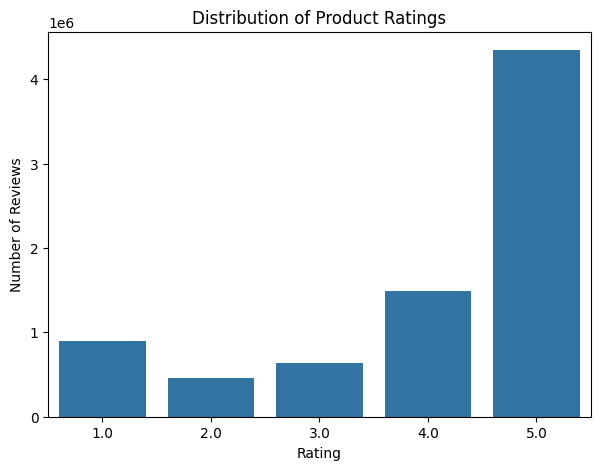

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
sentiment_data = pd.read_csv('/content/ratings_Electronics (1).csv', header=None)

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(sentiment_data.head())

# Display information about the dataset
print("\nDataset Information:")
sentiment_data.info()

sentiment_data.columns = ['UserID', 'ProductID', 'Rating', 'Timestamp']

print("\nDistribution of Ratings:")
print(sentiment_data['Rating'].value_counts())
print(sentiment_data['Rating'].value_counts(normalize=True))

# Visualize the distribution of ratings
plt.figure(figsize=(7, 5))
sns.countplot(x='Rating', data=sentiment_data)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

In [43]:
def assign_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

sentiment_data['Sentiment'] = sentiment_data['Rating'].apply(assign_sentiment)

print('\nSentiment Distribution:')
print(sentiment_data['Sentiment'].value_counts())
print(sentiment_data['Sentiment'].value_counts(normalize=True))


Sentiment Distribution:
Sentiment
positive    5833322
negative    1358087
neutral      633073
Name: count, dtype: int64
Sentiment
positive    0.745522
negative    0.173569
neutral     0.080909
Name: proportion, dtype: float64


In [44]:
from sklearn.preprocessing import LabelEncoder

# Encode sentiment labels to numerical values
label_encoder = LabelEncoder()
sentiment_data['Sentiment_Encoded'] = label_encoder.fit_transform(sentiment_data['Sentiment'])

# Map original sentiment labels to their encoded numerical values for reference
sentiment_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nSentiment Encoding Map: {sentiment_mapping}")

# Sort data by UserID and Timestamp to ensure correct sequence order
sentiment_data = sentiment_data.sort_values(by=['UserID', 'Timestamp'])

# Display the first few rows with the new encoded sentiment
print("\nFirst 5 rows of data with Encoded Sentiment:")
print(sentiment_data.head())


Sentiment Encoding Map: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

First 5 rows of data with Encoded Sentiment:
                        UserID   ProductID  Rating   Timestamp Sentiment  \
3588866  A00000262KYZUE4J55XGL  B003UYU16G     5.0  1353456000  positive   
3765420  A000063614T1OE0BUSKUT  B00419ZT3E     5.0  1365120000  positive   
3830822  A000063614T1OE0BUSKUT  B00432ZSHG     5.0  1365120000  positive   
6715223  A00009182QVLSWIGHLS1B  B009SXR7WE     5.0  1364947200  positive   
4120406  A00009661LC9LQPGKJ24G  B004GWQBWY     5.0  1351209600  positive   

         Sentiment_Encoded  
3588866                  2  
3765420                  2  
3830822                  2  
6715223                  2  
4120406                  2  


In [45]:
look_back_sentiment = 10 # Number of previous ratings to consider

def create_user_sequences(df, look_back):
    X, y = [], []
    for user_id, group in df.groupby('UserID'):
        if len(group) > look_back:
            for i in range(len(group) - look_back):
                X.append(group['Sentiment_Encoded'].iloc[i:(i + look_back)].values)
                y.append(group['Sentiment_Encoded'].iloc[i + look_back])
    return np.array(X), np.array(y)
sampled_users = sentiment_data['UserID'].unique()
if len(sampled_users) > 5000: # Limit to 5000 users for demonstration
    np.random.seed(42) # for reproducibility
    sampled_users = np.random.choice(sampled_users, 5000, replace=False)
sampled_sentiment_data = sentiment_data[sentiment_data['UserID'].isin(sampled_users)]

X_sentiment, y_sentiment = create_user_sequences(sampled_sentiment_data, look_back_sentiment)

print(f"Shape of X_sentiment (sequences): {X_sentiment.shape}")
print(f"Shape of y_sentiment (targets): {y_sentiment.shape}")

# Reshape X for LSTM [samples, time steps, features]
# Since each element in the sequence is a single feature (the encoded sentiment), the last dimension is 1
X_sentiment = np.reshape(X_sentiment, (X_sentiment.shape[0], X_sentiment.shape[1], 1))

print(f"Reshaped X_sentiment: {X_sentiment.shape}")

Shape of X_sentiment (sequences): (631, 10)
Shape of y_sentiment (targets): (631,)
Reshaped X_sentiment: (631, 10, 1)


In [46]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
num_sentiment_classes = len(sentiment_mapping)
X_train_sentiment, X_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(
    X_sentiment, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

print(f"X_train_sentiment shape: {X_train_sentiment.shape}, y_train_sentiment shape: {y_train_sentiment.shape}")
print(f"X_test_sentiment shape: {X_test_sentiment.shape}, y_test_sentiment shape: {y_test_sentiment.shape}")

model_sentiment = Sequential()
model_sentiment.add(LSTM(units=50, activation='relu', input_shape=(look_back_sentiment, 1)))
model_sentiment.add(Dense(units=num_sentiment_classes, activation='softmax'))
model_sentiment.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_sentiment.summary()

X_train_sentiment shape: (504, 10, 1), y_train_sentiment shape: (504,)
X_test_sentiment shape: (127, 10, 1), y_test_sentiment shape: (127,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,553 (41.22 KB)

 Trainable params: 10,553 (41.22 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
from sklearn.utils import class_weight

# Calculate class weights to handle potential class imbalance
class_weights_sentiment = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_sentiment),
    y=y_train_sentiment
)
class_weights_sentiment_dict = dict(enumerate(class_weights_sentiment))

print("Class weights for sentiment analysis:", class_weights_sentiment_dict)

# Train the model
history_sentiment = model_sentiment.fit(
    X_train_sentiment, y_train_sentiment,
    epochs=50, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    verbose=1, # Set to 1 for progress bar, 0 for silent
    validation_split=0.2, # Use a validation split to monitor overfitting
    class_weight=class_weights_sentiment_dict # Apply class weights during training
)

Class weights for sentiment analysis: {0: np.float64(3.2941176470588234), 1: np.float64(4.0), 2: np.float64(0.40875912408759124)}
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.0968 - loss: 1.1218 - val_accuracy: 0.1188 - val_loss: 1.1515
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1092 - loss: 1.1082 - val_accuracy: 0.3861 - val_loss: 1.1002
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1365 - loss: 1.1062 - val_accuracy: 0.0594 - val_loss: 1.0799
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4194 - loss: 1.1024 - val_accuracy: 0.5941 - val_loss: 1.0653
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5732 - loss: 1.1012 - val_accuracy: 0.5941 - val_loss: 1.0516
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4417 - loss: 1.0994 - val_accuracy: 0.4653 - val_loss: 1.0659
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4541 - loss: 1.0971 - val_accuracy: 0.5941 

In [48]:
# Evaluate the model
y_pred_proba_sentiment = model_sentiment.predict(X_test_sentiment)
y_pred_sentiment = np.argmax(y_pred_proba_sentiment, axis=1)

print("\nSentiment Analysis Model Evaluation:")
print("Accuracy:", accuracy_score(y_test_sentiment, y_pred_sentiment))
print("\nClassification Report:")
print(classification_report(y_test_sentiment, y_pred_sentiment, target_names=label_encoder.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_sentiment, y_pred_sentiment))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

Sentiment Analysis Model Evaluation:
Accuracy: 0.5905511811023622

Classification Report:
              precision    recall  f1-score   support

    negative       0.30      0.23      0.26        13
     neutral       0.09      0.27      0.14        11
    positive       0.82      0.67      0.74       103

    accuracy                           0.59       127
   macro avg       0.40      0.39      0.38       127
weighted avg       0.70      0.59      0.64       127


Confusion Matrix:
[[ 3  3  7]
 [ 0  3  8]
 [ 7 27 69]]


#Assignment 5

Use LSTM to analyze past sales data, holidays, and promotions to predict future inventory needs. Unlike simple averages, they can pick up on complex seasonality (e.g., "sales spike every third Thursday").retail_demand_data,csv


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load the dataset
demand_data = pd.read_csv('/content/retail_demand_data.csv')

print("Retail Demand Data Loaded.")

# Display the first few rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(demand_data.head())

# Display information about the dataset
print("\nDataset Information:")
demand_data.info()

# Display descriptive statistics
print("\nDescriptive statistics of the dataset:")
print(demand_data.describe())

# Check for missing values
print("\nMissing values per column:")
print(demand_data.isnull().sum())

Retail Demand Data Loaded.

First 5 rows of the dataset:
         date  day_of_week  is_weekend  is_third_thursday  on_promotion  \
0  2023-01-01            6           1                  0             0   
1  2023-01-02            0           0                  0             1   
2  2023-01-03            1           0                  0             0   
3  2023-01-04            2           0                  0             0   
4  2023-01-05            3           0                  0             0   

   units_sold  is_holiday  
0         548           0  
1         483           0  
2         519           0  
3         530           0  
4         527           0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               1000 non-null   object
 1   day_of_week        1000 non-null   int64 
 2   is_w

In [50]:
# Convert 'date' to datetime and set as index
demand_data['date'] = pd.to_datetime(demand_data['date'])
demand_data = demand_data.set_index('date')

# Define features and target
# Features will include 'day_of_week', 'is_weekend', 'is_third_thursday', 'on_promotion', 'is_holiday'
# The target is 'units_sold'
features_demand = demand_data.drop('units_sold', axis=1)
target_demand = demand_data['units_sold']

print("\nFeatures head:")
print(features_demand.head())
print("\nTarget head:")
print(target_demand.head())


Features head:
            day_of_week  is_weekend  is_third_thursday  on_promotion  \
date                                                                   
2023-01-01            6           1                  0             0   
2023-01-02            0           0                  0             1   
2023-01-03            1           0                  0             0   
2023-01-04            2           0                  0             0   
2023-01-05            3           0                  0             0   

            is_holiday  
date                    
2023-01-01           0  
2023-01-02           0  
2023-01-03           0  
2023-01-04           0  
2023-01-05           0  

Target head:
date
2023-01-01    548
2023-01-02    483
2023-01-03    519
2023-01-04    530
2023-01-05    527
Name: units_sold, dtype: int64


In [51]:
# Scale the features and target
# A separate scaler for features is good practice if you plan to inverse transform only predictions.
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaled_features_demand = scaler_features.fit_transform(features_demand)

scaler_target = MinMaxScaler(feature_range=(0, 1))
scaled_target_demand = scaler_target.fit_transform(target_demand.values.reshape(-1, 1))

print("\nShape of scaled features:", scaled_features_demand.shape)
print("Shape of scaled target:", scaled_target_demand.shape)


Shape of scaled features: (1000, 5)
Shape of scaled target: (1000, 1)


In [52]:
# Define look-back window and forecast horizon
look_back_demand = 30 # Number of previous time steps to use as input
forecast_horizon_demand = 1 # Number of future time steps to predict

# Function to create dataset with look-back windows for multiple features
def create_demand_dataset(features, target, look_back, forecast_horizon):
    X, Y = [], []
    for i in range(len(features) - look_back - forecast_horizon + 1):
        # Features for the current window
        X.append(features[i:(i + look_back), :])
        # Target for the forecast horizon
        Y.append(target[i + look_back : i + look_back + forecast_horizon, 0])
    return np.array(X), np.array(Y)


X_demand, y_demand = create_demand_dataset(scaled_features_demand, scaled_target_demand, look_back_demand, forecast_horizon_demand)

print(f"\nShape of X_demand (features sequences): {X_demand.shape}")
print(f"Shape of y_demand (target sequences): {y_demand.shape}")


Shape of X_demand (features sequences): (970, 30, 5)
Shape of y_demand (target sequences): (970, 1)


In [53]:
# Split data into training and testing sets
# Use a time-based split for time series data
train_size_demand = int(len(X_demand) * 0.8)

X_train_demand, X_test_demand = X_demand[0:train_size_demand,:], X_demand[train_size_demand:len(X_demand),:]
y_train_demand, y_test_demand = y_demand[0:train_size_demand,:], y_demand[train_size_demand:len(y_demand),:]

print(f"\nX_train_demand shape: {X_train_demand.shape}, y_train_demand shape: {y_train_demand.shape}")
print(f"X_test_demand shape: {X_test_demand.shape}, y_test_demand shape: {y_test_demand.shape}")


X_train_demand shape: (776, 30, 5), y_train_demand shape: (776, 1)
X_test_demand shape: (194, 30, 5), y_test_demand shape: (194, 1)


In [54]:
# Build the LSTM model for inventory prediction
n_features_demand = scaled_features_demand.shape[1]

model_demand = Sequential()
model_demand.add(LSTM(units=50, activation='relu', input_shape=(look_back_demand, n_features_demand)))
model_demand.add(Dense(units=forecast_horizon_demand)) # Output layer for regression
model_demand.compile(optimizer='adam', loss='mean_squared_error')

model_demand.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 50)             │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,251 (43.95 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0805 - val_loss: 0.0382
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0298 - val_loss: 0.0296
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0256 - val_loss: 0.0276
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0255 - val_loss: 0.0269
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0246 - val_loss: 0.0270
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0245 - val_loss: 0.0261
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0238 - val_loss: 0.0257
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0236 - val_loss: 0.0265
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0232 - val_loss: 0.0250
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0229 - val_loss: 0.0246
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0227 - val_loss: 0.0244
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Train RMSE (Inventory Prediction): 55.547, MAE: 45.279
Test RMSE (Inventory Prediction): 55.768, MAE: 44.521


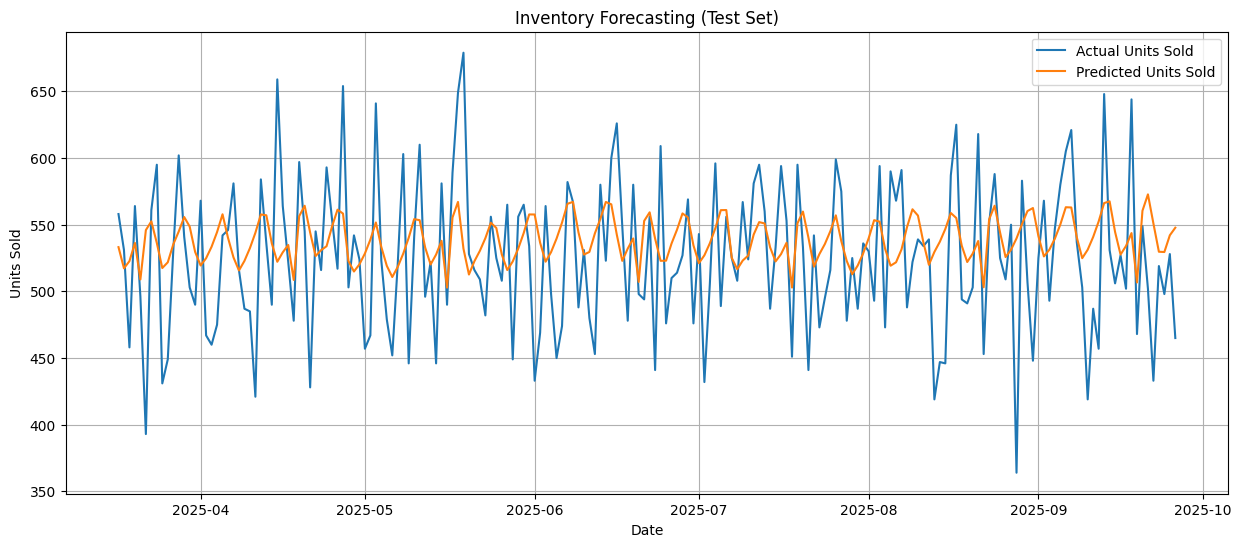

In [55]:
# Train the model
history_demand = model_demand.fit(
    X_train_demand, y_train_demand,
    epochs=50, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    verbose=1, # Set to 1 for progress bar, 0 for silent
    validation_split=0.2 # Use a validation split to monitor overfitting
)

# Make predictions
y_train_pred_demand = model_demand.predict(X_train_demand)
y_test_pred_demand = model_demand.predict(X_test_demand)

# Inverse transform predictions and actual values
y_train_pred_demand_inv = scaler_target.inverse_transform(y_train_pred_demand)
y_train_demand_inv = scaler_target.inverse_transform(y_train_demand)
y_test_pred_demand_inv = scaler_target.inverse_transform(y_test_pred_demand)
y_test_demand_inv = scaler_target.inverse_transform(y_test_demand)

# Calculate evaluation metrics
rmse_train_demand = np.sqrt(mean_squared_error(y_train_demand_inv, y_train_pred_demand_inv))
mae_train_demand = mean_absolute_error(y_train_demand_inv, y_train_pred_demand_inv)

rmse_test_demand = np.sqrt(mean_squared_error(y_test_demand_inv, y_test_pred_demand_inv))
mae_test_demand = mean_absolute_error(y_test_demand_inv, y_test_pred_demand_inv)

print(f'\nTrain RMSE (Inventory Prediction): {rmse_train_demand:.3f}, MAE: {mae_train_demand:.3f}')
print(f'Test RMSE (Inventory Prediction): {rmse_test_demand:.3f}, MAE: {mae_test_demand:.3f}')

# Plot actual vs. predicted (for a segment of the test data)
plt.figure(figsize=(15, 6))
plt.plot(demand_data.index[-len(y_test_demand_inv):], y_test_demand_inv, label='Actual Units Sold')
plt.plot(demand_data.index[-len(y_test_pred_demand_inv):], y_test_pred_demand_inv, label='Predicted Units Sold')
plt.title('Inventory Forecasting (Test Set)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.show()